# Predicción del desempeño académico mediante modelos de regresión

## Información del dataset

**Nombre:** Student Performance Factors Dataset

**Autor:** Abdel-Ghany, M. (2025)

**Fuente:** Kaggle

**Liga de acceso:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset

**Fecha de consulta:** 27 de agosto de 2026

### Contexto

El dataset Student Performance Factors contiene información relacionada con diferentes factores académicos,
personales, familiares y escolares de estudiantes. Cada registro representa a un estudiante y contiene
características asociadas con su contexto y desempeño, incluyendo el puntaje obtenido en un examen.

La variable objetivo será `Exam_Score`, que representa el puntaje obtenido por el estudiante en el examen.

### Pregunta predictiva

**¿En qué medida las características académicas, personales y escolares de los estudiantes permiten estimar
su puntaje de examen mediante modelos de regresión?**

El análisis comparará una línea base con una regresión lineal y un modelo Ridge, utilizando un flujo de
preprocesamiento reproducible para evitar fuga de información.

In [1]:
# Instalación de KaggleHub
!pip install -q kagglehub

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Carga del dataset

In [3]:
path = kagglehub.dataset_download(
    "mosapabdelghany/student-performance-factors-dataset"
)

print("Dataset descargado en:")
print(path)

print("\nArchivos disponibles:")
print(os.listdir(path))

100%|██████████| 93.9k/93.9k [00:00<00:00, 17.6MB/s]

Extracting files...
Dataset descargado en:
/root/.cache/kagglehub/datasets/mosapabdelghany/student-performance-factors-dataset/versions/1

Archivos disponibles:
['StudentPerformanceFactors.csv']


In [4]:
csv_files = [f for f in os.listdir(path) if f.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("No se encontró ningún archivo CSV en el dataset descargado.")

csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)

print("Archivo utilizado:", csv_path)
print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)

Archivo utilizado: /root/.cache/kagglehub/datasets/mosapabdelghany/student-performance-factors-dataset/versions/1/StudentPerformanceFactors.csv
Dataset cargado correctamente.
Dimensiones: (6607, 20)


## 2. Revisión inicial de la estructura

In [5]:
display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
filas, columnas = df.shape
print(f"Número de registros: {filas}")
print(f"Número de variables: {columnas}")

Número de registros: 6607
Número de variables: 20


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [8]:
estructura = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.astype(str),
    "Valores_nulos": df.isnull().sum(),
    "Valores_unicos": df.nunique()
})

display(estructura)

,Variable,Tipo,Valores_nulos,Valores_unicos
Hours_Studied,Hours_Studied,int64,0,41
Attendance,Attendance,int64,0,41
Parental_Involvement,Parental_Involvement,object,0,3
Access_to_Resources,Access_to_Resources,object,0,3
Extracurricular_Activities,Extracurricular_Activities,object,0,2
Sleep_Hours,Sleep_Hours,int64,0,7
Previous_Scores,Previous_Scores,int64,0,51
Motivation_Level,Motivation_Level,object,0,3
Internet_Access,Internet_Access,object,0,2
Tutoring_Sessions,Tutoring_Sessions,int64,0,9


In [9]:
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 0


## 3. Limpieza y preparación

Se conservará el mayor número posible de observaciones. Los duplicados completos se eliminan y los espacios
innecesarios en categorías se corrigen. Los valores faltantes no se eliminan de forma indiscriminada:
se imputarán dentro de los pipelines, de modo que los parámetros de imputación se aprendan únicamente
a partir del conjunto de entrenamiento.

In [10]:
df_clean = df.copy()

# Limpiar nombres de columnas
df_clean.columns = df_clean.columns.str.strip()

# Eliminar duplicados completos
antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
despues = len(df_clean)

print(f"Registros antes de eliminar duplicados: {antes}")
print(f"Registros después de eliminar duplicados: {despues}")
print(f"Duplicados eliminados: {antes - despues}")

# Estandarizar espacios en variables categóricas
categorical_columns_all = df_clean.select_dtypes(include=["object"]).columns

for col in categorical_columns_all:
    df_clean[col] = df_clean[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("\nValores faltantes por columna:")
display(df_clean.isnull().sum().sort_values(ascending=False).to_frame("Nulos"))

Registros antes de eliminar duplicados: 6607
Registros después de eliminar duplicados: 6607
Duplicados eliminados: 0

Valores faltantes por columna:


,Nulos
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67
Hours_Studied,0
Access_to_Resources,0
Parental_Involvement,0
Attendance,0
Extracurricular_Activities,0
Motivation_Level,0
Internet_Access,0


## 4. Exploración de la variable objetivo: `Exam_Score`

In [11]:
if "Exam_Score" not in df_clean.columns:
    raise KeyError("La columna 'Exam_Score' no está presente en el dataset.")

display(df_clean["Exam_Score"].describe().to_frame("Exam_Score"))

,Exam_Score
count,6607.000000
mean,67.235659
std,3.890456
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,101.000000


In [12]:
print("Media:", df_clean["Exam_Score"].mean())
print("Mediana:", df_clean["Exam_Score"].median())
print("Desviación estándar:", df_clean["Exam_Score"].std())
print("Mínimo:", df_clean["Exam_Score"].min())
print("Máximo:", df_clean["Exam_Score"].max())

Media: 67.23565914938702
Mediana: 67.0
Desviación estándar: 3.890455781261724
Mínimo: 55
Máximo: 101


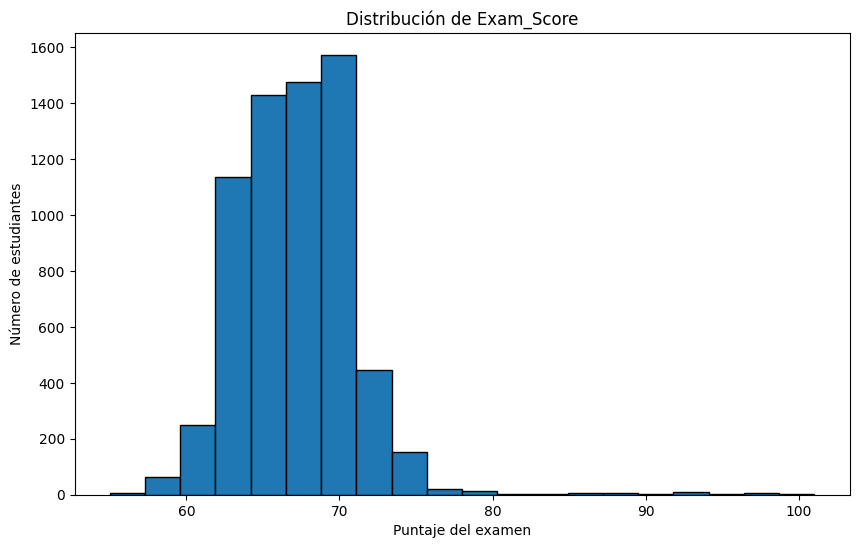

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["Exam_Score"], bins=20, edgecolor="black")
plt.title("Distribución de Exam_Score")
plt.xlabel("Puntaje del examen")
plt.ylabel("Número de estudiantes")
plt.show()

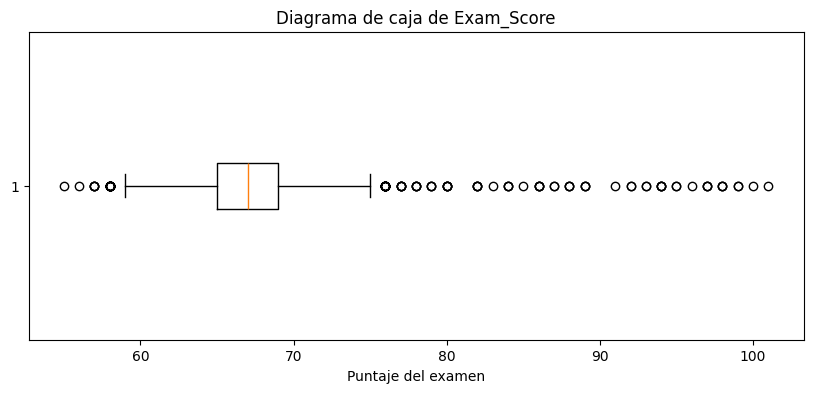

In [14]:
plt.figure(figsize=(10, 4))
plt.boxplot(df_clean["Exam_Score"], vert=False)
plt.title("Diagrama de caja de Exam_Score")
plt.xlabel("Puntaje del examen")
plt.show()

## 5. Relación entre `Exam_Score` y los predictores

In [15]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns

print("Variables numéricas:")
print(list(numeric_columns))

Variables numéricas:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


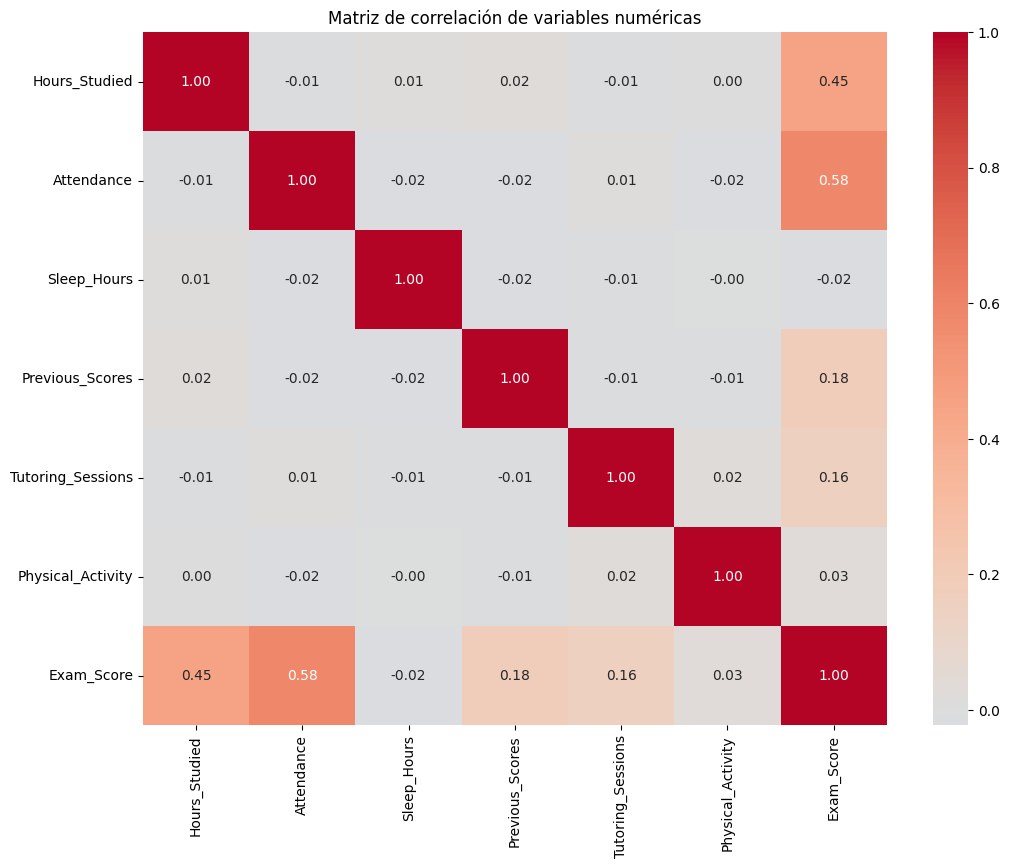

In [16]:
correlation = df_clean[numeric_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

In [17]:
correlation_exam = correlation["Exam_Score"].sort_values(ascending=False)
display(correlation_exam.to_frame("Correlación_con_Exam_Score"))

,Correlación_con_Exam_Score
Exam_Score,1.000000
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


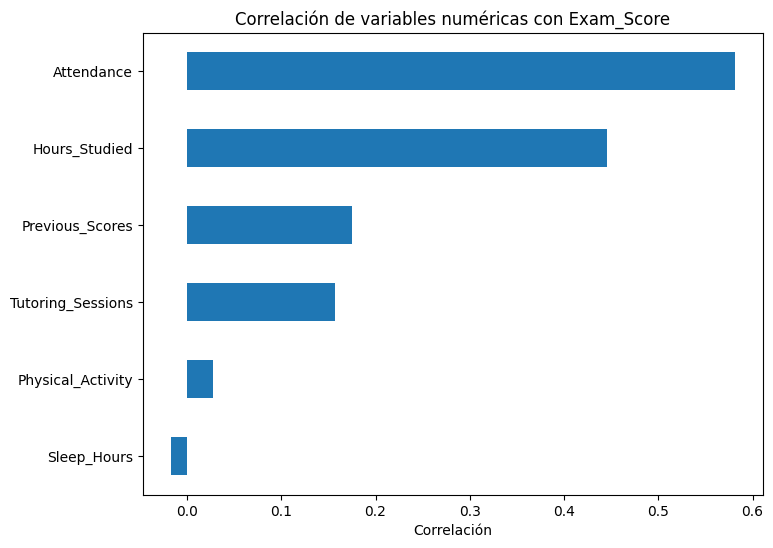

In [18]:
plt.figure(figsize=(8, 6))
correlation_exam.drop("Exam_Score").sort_values().plot(kind="barh")
plt.title("Correlación de variables numéricas con Exam_Score")
plt.xlabel("Correlación")
plt.show()

### Diagramas de dispersión

Se revisarán tres variables numéricas con una relación conceptualmente relevante con el desempeño:
horas de estudio, asistencia y puntuaciones previas.

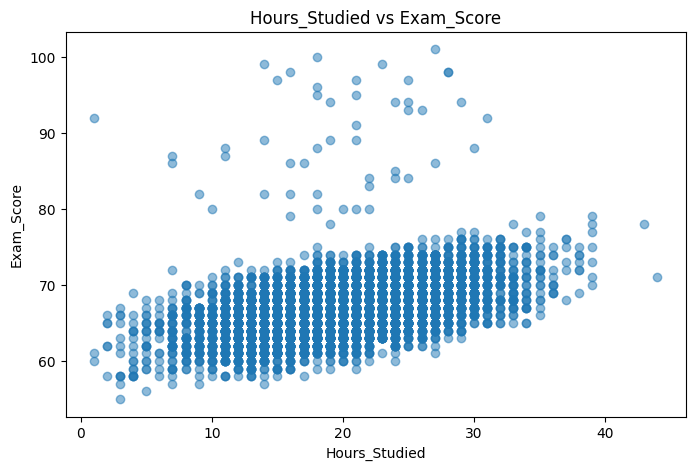

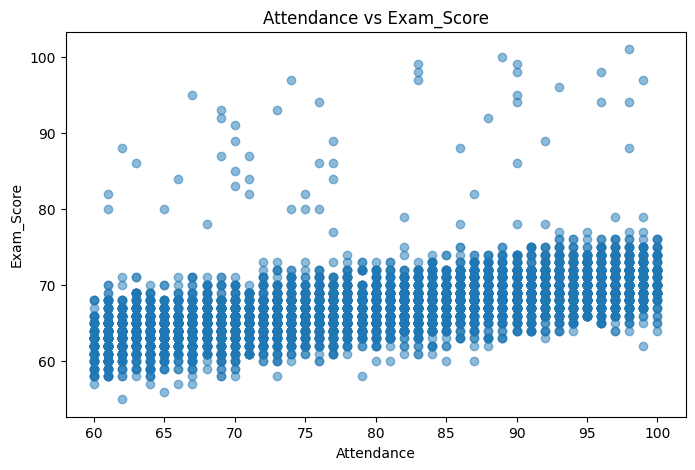

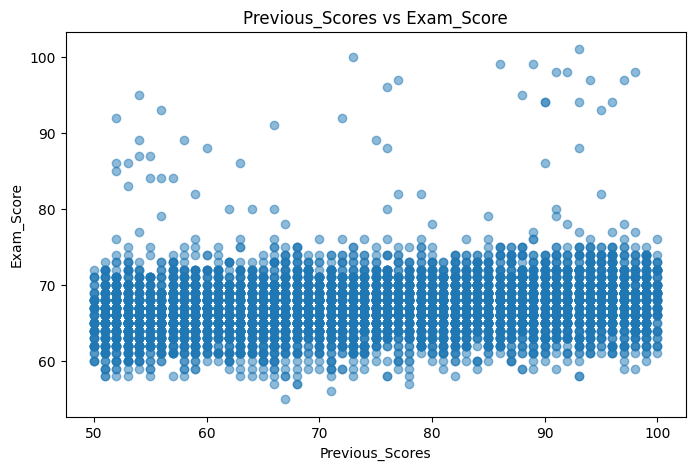

In [19]:
variables_scatter = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores"
]

missing_scatter = [v for v in variables_scatter if v not in df_clean.columns]

if missing_scatter:
    print("No se encontraron:", missing_scatter)
else:
    for variable in variables_scatter:
        plt.figure(figsize=(8, 5))
        plt.scatter(
            df_clean[variable],
            df_clean["Exam_Score"],
            alpha=0.5
        )
        plt.title(f"{variable} vs Exam_Score")
        plt.xlabel(variable)
        plt.ylabel("Exam_Score")
        plt.show()

### Comparación por categorías

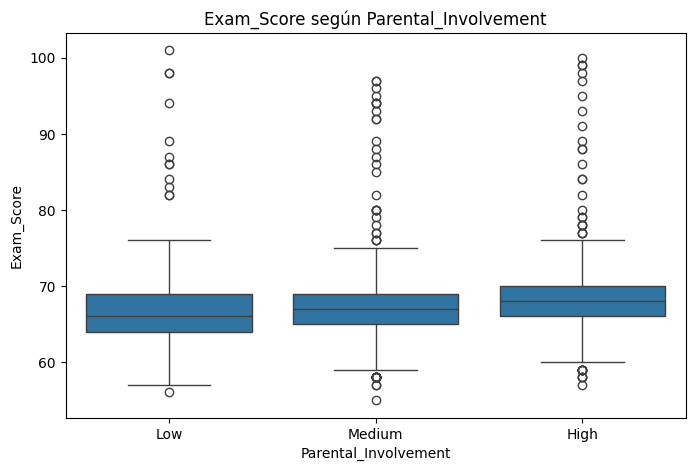

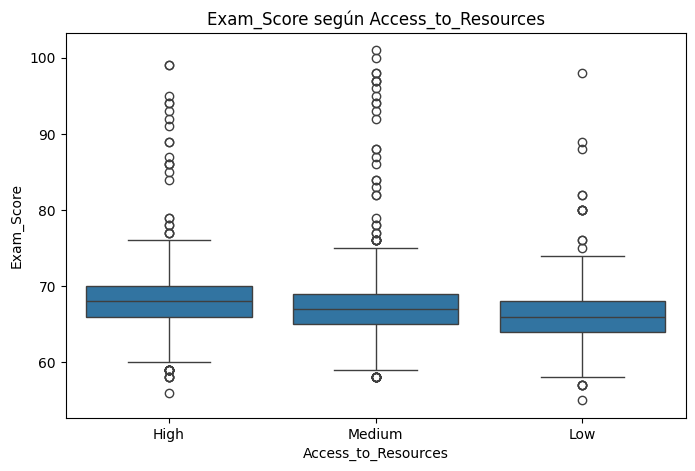

In [20]:
categorical_to_plot = ["Parental_Involvement", "Access_to_Resources"]

for variable in categorical_to_plot:
    if variable in df_clean.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(
            data=df_clean,
            x=variable,
            y="Exam_Score"
        )
        plt.title(f"Exam_Score según {variable}")
        plt.xlabel(variable)
        plt.ylabel("Exam_Score")
        plt.show()

### Selección de variables

Se seleccionan variables que representan diferentes dimensiones del desempeño: factores académicos,
personales, familiares, escolares y sociales. La selección se apoya tanto en la interpretación contextual
como en la exploración de las relaciones observadas.

In [21]:
selected_numeric = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Sleep_Hours",
    "Physical_Activity"
]

selected_categorical = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Teacher_Quality",
    "Peer_Influence"
]

selected_features = selected_numeric + selected_categorical

missing_features = [c for c in selected_features if c not in df_clean.columns]
if missing_features:
    raise KeyError(f"Faltan columnas esperadas: {missing_features}")

X = df_clean[selected_features]
y = df_clean["Exam_Score"]

print("Variables predictoras:")
print(selected_features)
print("\nVariable objetivo: Exam_Score")

Variables predictoras:
['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Sleep_Hours', 'Physical_Activity', 'Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Teacher_Quality', 'Peer_Influence']

Variable objetivo: Exam_Score


`Hours_Studied`, `Attendance` y `Previous_Scores` incorporan información directamente relacionada con el
trabajo y desempeño académico. `Tutoring_Sessions` representa apoyo educativo adicional, mientras que
`Sleep_Hours` y `Physical_Activity` incorporan factores personales. Las variables categóricas agregan
información familiar, escolar y social que puede complementar los factores académicos.

## 6. División de entrenamiento y prueba

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5285, 11)
Prueba: (1322, 11)


Se utiliza una proporción de 80 % para entrenamiento y 20 % para prueba. La semilla fija `42` permite
reproducir exactamente la misma partición al volver a ejecutar el notebook, facilitando la comparación
consistente entre modelos.

## 7. Flujo de preprocesamiento

In [23]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selected_numeric),
        ("cat", categorical_transformer, selected_categorical)
    ]
)

print("Preprocesador configurado correctamente.")

Preprocesador configurado correctamente.


El `ColumnTransformer` aplica transformaciones distintas según el tipo de variable. Las variables numéricas
se imputan con la mediana y se estandarizan; las categóricas se imputan con la categoría más frecuente y
se codifican mediante One-Hot Encoding. Al estar dentro de pipelines, las transformaciones se ajustan
únicamente con los datos de entrenamiento, evitando fuga de información.

## 8. Línea base

In [24]:
baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

## 9. Modelo 1: Regresión lineal

In [25]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

## 10. Modelo 2: Ridge Regression

Ridge se utiliza como alternativa a la regresión lineal. Añade regularización L2, lo que ayuda a controlar
coeficientes grandes y puede ser útil cuando el One-Hot Encoding genera un número considerable de variables.

In [26]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

## 11. Evaluación mediante MAE, RMSE y R²

In [27]:
def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return {
        "Modelo": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

results = pd.DataFrame([
    evaluate_model("Línea base", y_test, baseline_pred),
    evaluate_model("Regresión lineal", y_test, linear_pred),
    evaluate_model("Ridge", y_test, ridge_pred)
])

display(results.style.format({
    "MAE": "{:.4f}",
    "RMSE": "{:.4f}",
    "R²": "{:.4f}"
}))

,Modelo,MAE,RMSE,R²
0,Línea base,2.8235,3.7611,-0.0007
1,Regresión lineal,0.7786,1.9401,0.7337
2,Ridge,0.7786,1.9401,0.7337


### Interpretación de las métricas

**MAE (Mean Absolute Error):** representa el error absoluto promedio entre el puntaje real y el predicho.
Está expresado en puntos de `Exam_Score`, por lo que indica directamente cuántos puntos se equivoca
el modelo en promedio.

**RMSE (Root Mean Squared Error):** también está expresado en puntos, pero penaliza más los errores grandes
porque primero eleva las diferencias al cuadrado. Por ello, un RMSE considerablemente superior al MAE
puede indicar la presencia de algunas predicciones con errores elevados.

**R²:** indica qué proporción de la variabilidad observada en `Exam_Score` puede explicar el modelo.
Un valor cercano a 1 representa un mejor ajuste, mientras que un valor cercano a 0 significa que el modelo
explica poca variabilidad adicional frente a una predicción constante basada en la media.

Las métricas deben interpretarse considerando la escala real de `Exam_Score`. Por ejemplo, un MAE de 2
significaría que las predicciones se alejan aproximadamente 2 puntos del resultado real en promedio.

In [28]:
best_model_name = results.loc[results["RMSE"].idxmin(), "Modelo"]

model_predictions = {
    "Regresión lineal": linear_pred,
    "Ridge": ridge_pred
}

model_objects = {
    "Regresión lineal": linear_model,
    "Ridge": ridge_model
}

print("Mejor modelo según RMSE:", best_model_name)

Mejor modelo según RMSE: Ridge


## 12. Comparación de modelos

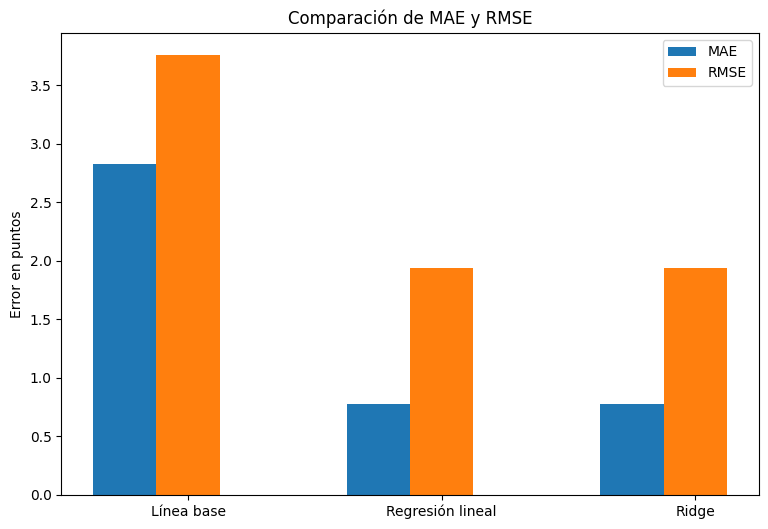

In [29]:
plt.figure(figsize=(9, 6))

x = np.arange(len(results))
width = 0.25

plt.bar(x - width, results["MAE"], width, label="MAE")
plt.bar(x, results["RMSE"], width, label="RMSE")

plt.xticks(x, results["Modelo"])
plt.ylabel("Error en puntos")
plt.title("Comparación de MAE y RMSE")
plt.legend()
plt.show()

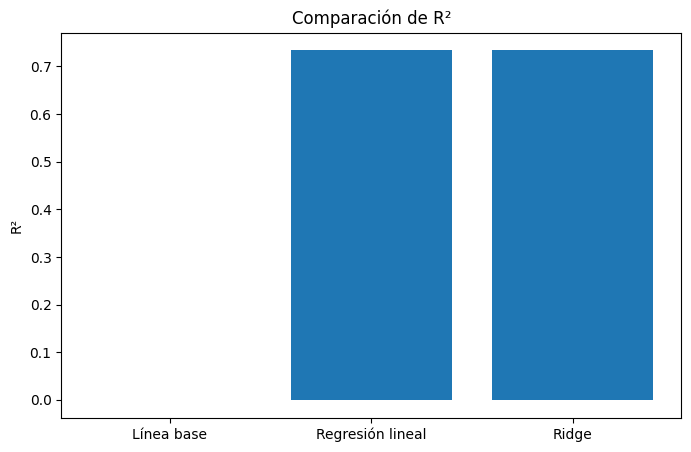

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(results["Modelo"], results["R²"])
plt.ylabel("R²")
plt.title("Comparación de R²")
plt.show()

## 13. Valores reales contra valores predichos

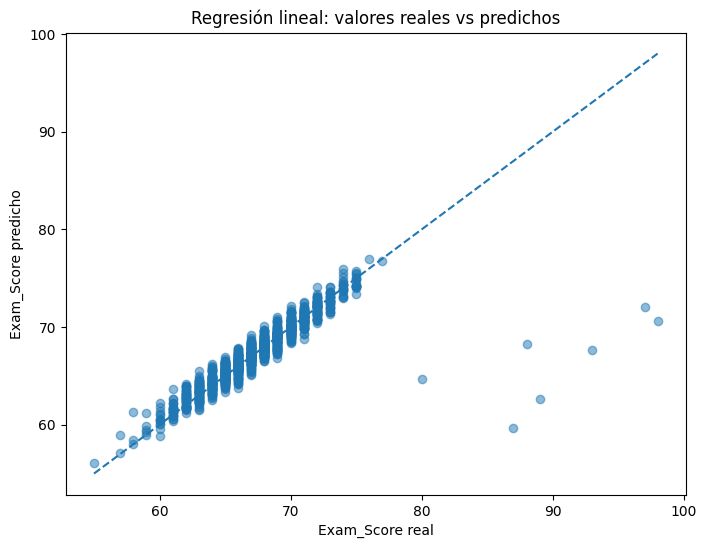

In [31]:
# Regresión lineal
plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred, alpha=0.5)

min_value = min(y_test.min(), linear_pred.min())
max_value = max(y_test.max(), linear_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Regresión lineal: valores reales vs predichos")
plt.xlabel("Exam_Score real")
plt.ylabel("Exam_Score predicho")
plt.show()

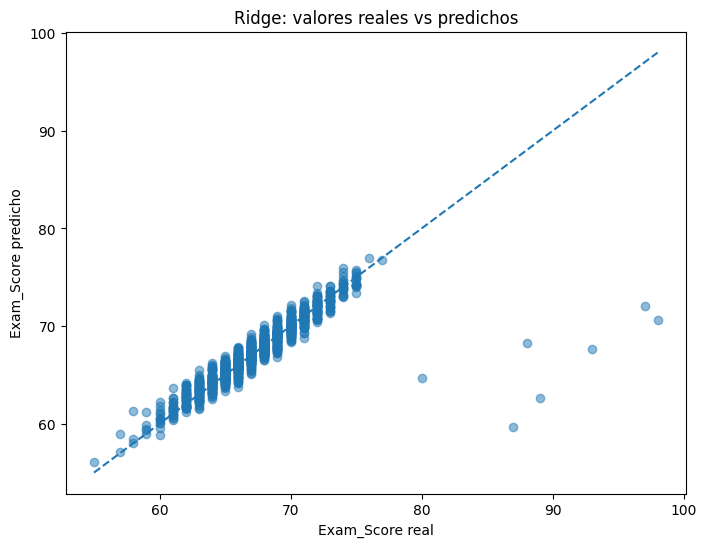

In [32]:
# Ridge
plt.figure(figsize=(8, 6))
plt.scatter(y_test, ridge_pred, alpha=0.5)

min_value = min(y_test.min(), ridge_pred.min())
max_value = max(y_test.max(), ridge_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Ridge: valores reales vs predichos")
plt.xlabel("Exam_Score real")
plt.ylabel("Exam_Score predicho")
plt.show()

La línea diagonal representa predicciones perfectas. Cuanto más cerca se encuentren los puntos de esta
línea, menor es el error de predicción.

## 14. Análisis de residuos del mejor modelo

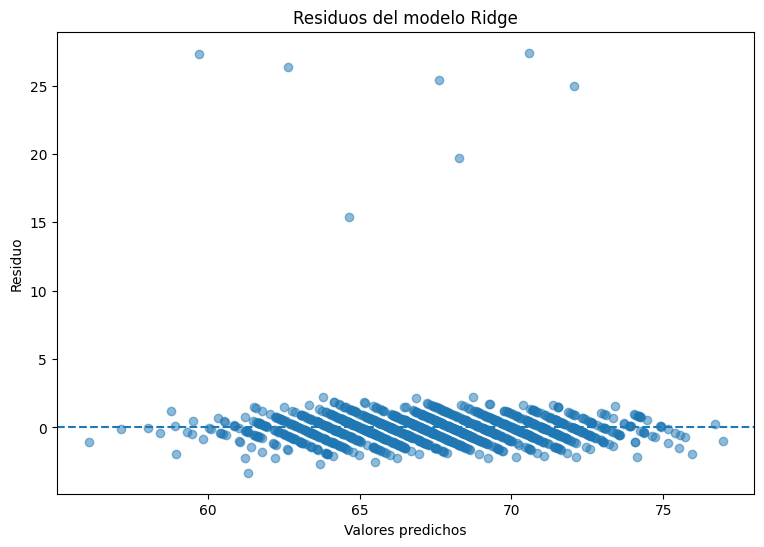

In [33]:
best_predictions = model_predictions[best_model_name]
residuals = y_test - best_predictions

plt.figure(figsize=(9, 6))
plt.scatter(best_predictions, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.title(f"Residuos del modelo {best_model_name}")
plt.xlabel("Valores predichos")
plt.ylabel("Residuo")
plt.show()

En un modelo adecuado se espera que los residuos se distribuyan alrededor de cero sin patrones claramente
definidos. Una distribución aproximadamente aleatoria sugiere que no existe un patrón sistemático evidente
en los errores. Agrupamientos, tendencias, dispersión creciente o valores extremos pueden indicar que el
modelo no captura completamente la relación entre los predictores y el puntaje.

## 15. Observaciones con mayor y menor error

In [34]:
error_analysis = X_test.copy()

error_analysis["Exam_Score_Real"] = y_test.values
error_analysis["Exam_Score_Predicho"] = best_predictions
error_analysis["Error"] = (
    error_analysis["Exam_Score_Real"]
    - error_analysis["Exam_Score_Predicho"]
)
error_analysis["Error_Absoluto"] = error_analysis["Error"].abs()

error_analysis = error_analysis.sort_values(
    "Error_Absoluto",
    ascending=False
)

print("=== CASOS CON MAYOR ERROR ===")
display(error_analysis.head(10))

=== CASOS CON MAYOR ERROR ===


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Physical_Activity,Parental_Involvement,Access_to_Resources,Motivation_Level,Teacher_Quality,Peer_Influence,Exam_Score_Real,Exam_Score_Predicho,Error,Error_Absoluto
4192,28,90,91,0,9,2,Low,Medium,Medium,Medium,Positive,98,70.588108,27.411892,27.411892
2687,11,71,55,1,8,3,Low,Medium,Medium,Medium,Negative,87,59.699646,27.300354,27.300354
217,19,70,54,0,7,2,Medium,Low,High,Medium,Positive,89,62.637064,26.362936,26.362936
4531,26,69,95,0,7,3,High,High,Low,Medium,Negative,93,67.613556,25.386444,25.386444
5966,25,99,77,0,7,3,Medium,Medium,Medium,High,Neutral,97,72.047157,24.952843,24.952843
2513,18,86,60,2,8,1,High,Medium,Medium,High,Neutral,88,68.288712,19.711288,19.711288
5989,18,61,91,3,6,3,Medium,Low,High,High,Positive,80,64.642587,15.357413,15.357413
5198,15,60,63,0,7,1,High,Medium,Low,High,Positive,58,61.315734,-3.315734,3.315734
1183,11,62,87,3,7,3,Low,High,High,High,Positive,61,63.684868,-2.684868,2.684868
833,15,71,60,5,8,4,Low,Medium,High,High,Positive,63,65.520686,-2.520686,2.520686


In [35]:
print("=== CASOS CON MAYOR PRECISIÓN ===")
display(
    error_analysis.sort_values("Error_Absoluto").head(10)
)

=== CASOS CON MAYOR PRECISIÓN ===


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Physical_Activity,Parental_Involvement,Access_to_Resources,Motivation_Level,Teacher_Quality,Peer_Influence,Exam_Score_Real,Exam_Score_Predicho,Error,Error_Absoluto
2746,21,72,80,1,9,3,Medium,High,Low,Medium,Neutral,66,66.001975,-0.001975,0.001975
468,17,83,80,4,9,2,Low,Medium,Medium,High,Negative,67,66.997775,0.002225,0.002225
1084,22,97,88,1,6,4,Medium,Medium,High,Low,Positive,72,72.003720,-0.003720,0.003720
2471,34,74,76,2,7,2,High,Low,Medium,High,Positive,71,70.996047,0.003953,0.003953
5548,17,77,77,0,4,4,High,Medium,Low,Medium,Positive,66,65.995590,0.004410,0.004410
5303,23,67,98,2,9,0,Low,Low,Medium,High,Negative,64,64.005233,-0.005233,0.005233
1057,27,89,65,1,7,3,Medium,Medium,Medium,Medium,Neutral,70,70.005733,-0.005733,0.005733
5196,26,98,90,1,8,2,High,Low,Low,Low,Positive,72,72.007383,-0.007383,0.007383
5307,15,72,80,4,9,4,Medium,Low,Medium,High,Neutral,65,64.991948,0.008052,0.008052
4986,19,96,71,2,7,3,Low,Medium,Medium,High,Positive,70,69.989496,0.010504,0.010504


Los casos con mayor error representan estudiantes cuyo puntaje fue difícil de estimar con las variables
seleccionadas. Las diferencias pueden deberse a combinaciones particulares de factores, variables no
observadas o relaciones no lineales que los modelos utilizados no capturan completamente.

La comparación de casos con errores altos y bajos permite identificar posibles limitaciones de los datos,
del preprocesamiento o del tipo de modelo.

## 16. Validación cruzada K-Fold

In [36]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

best_model = model_objects[best_model_name]

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("RMSE de cada partición:")
for i, score in enumerate(cv_rmse, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nRMSE promedio: {cv_rmse.mean():.4f}")
print(f"Desviación estándar: {cv_rmse.std():.4f}")

RMSE de cada partición:
Fold 1: 2.1917
Fold 2: 2.2623
Fold 3: 1.9507
Fold 4: 2.4698
Fold 5: 2.2782

RMSE promedio: 2.2305
Desviación estándar: 0.1675


In [37]:
test_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

comparison_cv = pd.DataFrame({
    "Evaluación": [
        "Una sola partición (test)",
        "Validación cruzada (media)"
    ],
    "RMSE": [
        test_rmse,
        cv_rmse.mean()
    ]
})

display(comparison_cv.style.format({"RMSE": "{:.4f}"}))

,Evaluación,RMSE
0,Una sola partición (test),1.9401
1,Validación cruzada (media),2.2305


La evaluación con una sola partición depende de qué observaciones hayan quedado en entrenamiento y cuáles
en prueba. En cambio, K-Fold entrena y evalúa el modelo varias veces con diferentes particiones del conjunto
de entrenamiento. Por ello, la media de RMSE proporciona una referencia más estable y la desviación estándar
muestra cuánto varía el desempeño entre particiones.

La validación cruzada se realiza sobre `X_train` e `y_train`, mientras que el conjunto de prueba se mantiene
separado para conservar una evaluación independiente.

## 17. Variables más relevantes mediante Permutation Importance

In [38]:
from sklearn.inspection import permutation_importance

def grouped_permutation_importance(
    model,
    X,
    y,
    repeats=5,
    random_state=42
):
    rng = np.random.RandomState(random_state)

    baseline_rmse = np.sqrt(
        mean_squared_error(y, model.predict(X))
    )

    importance_results = []
    X_copy = X.copy()

    for column in X.columns:
        scores = []

        for _ in range(repeats):
            X_permuted = X_copy.copy()
            X_permuted[column] = rng.permutation(
                X_permuted[column].values
            )

            predictions = model.predict(X_permuted)

            rmse = np.sqrt(
                mean_squared_error(y, predictions)
            )

            scores.append(rmse)

        importance_results.append({
            "Variable": column,
            "Aumento_RMSE": np.mean(scores) - baseline_rmse
        })

    return (
        pd.DataFrame(importance_results)
        .sort_values("Aumento_RMSE", ascending=False)
    )

grouped_importance = grouped_permutation_importance(
    best_model,
    X_test,
    y_test,
    repeats=5,
    random_state=RANDOM_STATE
)

display(grouped_importance)

,Variable,Aumento_RMSE
1,Attendance,1.832630
0,Hours_Studied,1.241851
7,Access_to_Resources,0.235108
6,Parental_Involvement,0.224265
2,Previous_Scores,0.212988
3,Tutoring_Sessions,0.165548
8,Motivation_Level,0.075443
10,Peer_Influence,0.070314
9,Teacher_Quality,0.051285
5,Physical_Activity,0.017107


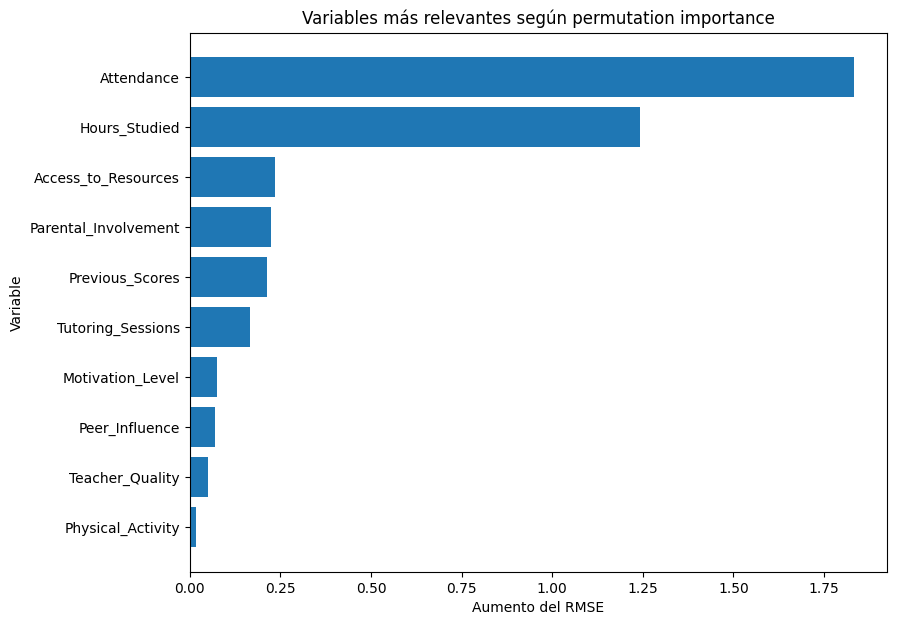

In [39]:
top_importance = grouped_importance.head(10).sort_values("Aumento_RMSE")

plt.figure(figsize=(9, 7))
plt.barh(
    top_importance["Variable"],
    top_importance["Aumento_RMSE"]
)

plt.xlabel("Aumento del RMSE")
plt.ylabel("Variable")
plt.title("Variables más relevantes según permutation importance")
plt.show()

Una variable que provoca un mayor aumento del RMSE al ser permutada suele tener mayor importancia para
las predicciones del modelo. Esta técnica permite interpretar las variables originales incluso cuando
las categóricas fueron transformadas mediante One-Hot Encoding.

## 18. Resultados finales y mejora frente a la línea base

In [40]:
best_row = results.loc[results["RMSE"].idxmin()]
baseline_row = results[results["Modelo"] == "Línea base"].iloc[0]

improvement_rmse = (
    (baseline_row["RMSE"] - best_row["RMSE"])
    / baseline_row["RMSE"]
) * 100

print(f"Mejor modelo: {best_row['Modelo']}")
print(f"MAE: {best_row['MAE']:.4f}")
print(f"RMSE: {best_row['RMSE']:.4f}")
print(f"R²: {best_row['R²']:.4f}")
print(f"RMSE de línea base: {baseline_row['RMSE']:.4f}")
print(f"Mejora del RMSE respecto a la línea base: {improvement_rmse:.2f}%")
print(f"RMSE promedio CV: {cv_rmse.mean():.4f}")
print(f"Desviación estándar CV: {cv_rmse.std():.4f}")

Mejor modelo: Ridge
MAE: 0.7786
RMSE: 1.9401
R²: 0.7337
RMSE de línea base: 3.7611
Mejora del RMSE respecto a la línea base: 48.42%
RMSE promedio CV: 2.2305
Desviación estándar CV: 0.1675


# 19. Conclusión

El análisis permitió evaluar en qué medida diferentes características académicas, personales, familiares,
escolares y sociales permiten estimar `Exam_Score` mediante modelos de regresión.

Después de realizar la limpieza y el preprocesamiento de los datos se comparó una línea base basada en la
media del puntaje con una regresión lineal y un modelo Ridge. El modelo que obtuvo el mejor desempeño fue
el que presentó el menor RMSE, considerando también MAE y R².

La mejora respecto de la línea base indica si utilizar las características de los estudiantes permite
realizar predicciones más informativas que asignar a todos el puntaje promedio. Los resultados de
permutation importance permiten identificar cuáles variables fueron más relevantes para el modelo.

El análisis de residuos debe utilizarse para revisar si los errores se distribuyen aproximadamente de forma
aleatoria o si aparecen patrones y valores extremos. Los casos con errores absolutos altos pueden revelar
estudiantes cuyo desempeño no puede explicarse adecuadamente mediante las variables disponibles.

La validación cruzada de cinco particiones proporciona una referencia más estable del desempeño del modelo
que una sola división de entrenamiento y prueba, además de mostrar la variabilidad entre diferentes
particiones.

En general, el modelo debe considerarse una primera aproximación para estimar el desempeño académico y no
como una herramienta suficiente para tomar decisiones académicas importantes. Como trabajo posterior sería
conveniente probar modelos capaces de capturar relaciones no lineales, ajustar hiperparámetros, incorporar
variables adicionales y validar el modelo con datos externos antes de utilizarlo en un contexto real.